## 0. Install Dependencies

In [ ]:
!pip install datasets pandas scikit-learn matplotlib seaborn --quiet

## 1. Imports & Setup

In [ ]:
import re
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split

os.makedirs("data", exist_ok=True)
print("All imports successful.")

All imports successful.


## 2. Load Raw Dataset
Load directly from Hugging Face Hub — no manual download needed.

In [ ]:
ds = load_dataset("DoDataThings/us-bank-transaction-categories-v2")
df = ds["train"].to_pandas()

print(f"Total rows   : {len(df):,}")
print(f"Columns      : {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
df.head(5)

Total rows   : 68,000
Columns      : ['description', 'category']

Dtypes:
description    object
category       object
dtype: object


,description,category
0,[debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 99...,Insurance
1,[debit] MTG PMT PENFED CU,Mortgage
2,[debit] BETMGM 147 PARK BLVD UNION CITY 94587 ...,Entertainment
3,[debit] REPUBLIC SERVICES 222 MISSION CT CHICA...,Utilities
4,[debit] PYPL*365 MARKET,Groceries


## 3. Inspect Raw Data
### 3.1 Size, Structure & Quality Issues

In [ ]:
# Missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Exact duplicates
n_dupes = df.duplicated().sum()
print(f"\n=== Exact Duplicate Rows === {n_dupes}")

# Description length stats
df["raw_len"] = df["description"].str.len()
print(f"\n=== Description Length ===")
print(df["raw_len"].describe().round(1))

=== Missing Values ===
description    0
category       0
dtype: int64

=== Exact Duplicate Rows === 22298

=== Description Length ===
count    68000.0
mean        35.9
std         14.2
min         10.0
25%         25.0
50%         32.0
75%         47.0
max        105.0
Name: raw_len, dtype: float64


### 3.2 Class Distribution (Raw)

category
Insurance         4000
Mortgage          4000
Entertainment     4000
Utilities         4000
Groceries         4000
Personal Care     4000
Shopping          4000
Subscription      4000
Healthcare        4000
Rent              4000
Fees              4000
Income            4000
Transportation    4000
Education         4000
Restaurants       4000
Transfer          4000
Travel            4000

Unique categories: 17


/tmp/ipykernel_2923/616755891.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")


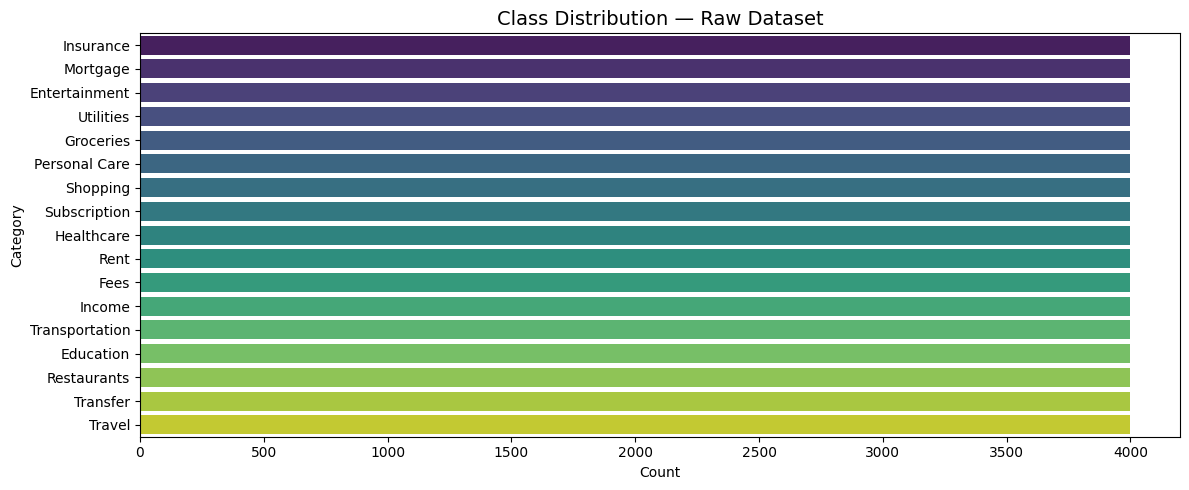

In [ ]:
class_counts = df["category"].value_counts()
print(class_counts.to_string())
print(f"\nUnique categories: {df['category'].nunique()}")

plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Class Distribution — Raw Dataset", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### 3.3 Sample Raw Descriptions

In [ ]:
df[["description", "category"]].sample(10, random_state=42)

,description,category
23742,[debit] CHOICE HOME WARRANTY 5153 OAK LN CHICA...,Insurance
59794,[debit] KHAN ACADEMY 667 ELM RD NEWARK 07101 N...,Education
17596,[debit] OVERDRAFT FEE,Fees
27986,[debit] CVS,Healthcare
45428,[debit] Brilliant.org; Service,Education
14111,[debit] ARCO,Transportation
29019,[debit] DOCTOR ON DEMAND TELEHEALTH,Healthcare
33373,[debit] Subscription Payment: PROTONVPN,Subscription
33792,[debit] LINCOLN PROPERTY RENT PAYMENT,Rent
51422,[debit] EXXON - SAN JOSE,Transportation


## 4. Data Cleaning & Normalisation
All steps below are specific to the **Text** modality as required by Task 2.

| Step | Justification |
|------|--------------|
| Drop nulls | Model cannot train on empty inputs |
| Strip whitespace | Normalises formatting |
| Remove exact duplicates | Prevents data leakage across train/val split |
| Extract `[debit]`/`[credit]` prefix | Direction is meaningful — same merchant string means different categories depending on sign |
| Lowercase merchant body | Reduces vocabulary; DistilBERT is uncased |
| Strip terminal IDs / zip codes / store numbers | Pure noise that doesn't help categorisation |
| Rebuild unified `text` column | Clean, single input field for tokenizer |


### 4.1 Drop Missing Values

In [ ]:
before = len(df)
df = df.dropna(subset=["description", "category"])
df["description"] = df["description"].str.strip()
print(f"Rows dropped (missing): {before - len(df)}")
print(f"Remaining: {len(df):,}")

Rows dropped (missing): 0
Remaining: 68,000


### 4.2 Remove Exact Duplicates

In [ ]:
before = len(df)
df = df.drop_duplicates(subset=["description", "category"])
print(f"Rows dropped (duplicates): {before - len(df)}")
print(f"Remaining: {len(df):,}")

Rows dropped (duplicates): 22298
Remaining: 45,702


### 4.3 Extract & Normalise Sign Prefix
The `[debit]` / `[credit]` tag encodes transaction direction — crucial for disambiguation  
e.g. `[credit] VENMO CASHOUT` = Income vs `[debit] VENMO CASHOUT` = Transfer.

In [ ]:
def extract_sign_prefix(text: str) -> str:
    m = re.match(r"^\[(debit|credit)\]", text.strip(), re.IGNORECASE)
    return m.group(1).lower() if m else "unk"

def strip_sign_prefix(text: str) -> str:
    return re.sub(r"^\[(debit|credit)\]\s*", "", text.strip(), flags=re.IGNORECASE)

df["sign"]             = df["description"].apply(extract_sign_prefix)
df["description_body"] = df["description"].apply(strip_sign_prefix)

print("Sign prefix distribution:")
print(df["sign"].value_counts().to_string())

Sign prefix distribution:
sign
debit     40053
credit     5649


### 4.4 Lowercase + Strip Terminal Numbers / IDs / Zip Codes

In [ ]:
def clean_merchant_string(text: str) -> str:
    text = text.lower()
    # Remove PPD / WEB IDs e.g. "PPD ID: 9901629141"
    text = re.sub(r"\b(ppd|web)\s+id:\s*\S+", "", text, flags=re.IGNORECASE)
    # Remove reference numbers (6+ digits)
    text = re.sub(r"\b\d{6,}\b", "", text)
    # Remove store numbers like "#00123"
    text = re.sub(r"#\d+", "", text)
    # Remove 5-digit zip codes
    text = re.sub(r"\b\d{5}(-\d{4})?\b", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s{2,}", " ", text).strip()
    return text

df["description_clean"] = df["description_body"].apply(clean_merchant_string)

# Drop rows where cleaning left empty string
before = len(df)
df = df[df["description_clean"].str.len() > 0]
print(f"Rows dropped (empty after cleaning): {before - len(df)}")
print(f"Remaining: {len(df):,}")

Rows dropped (empty after cleaning): 0
Remaining: 45,702


### 4.5 Build Final `text` Column

In [ ]:
# Final input: "<sign> <cleaned_merchant>"
df["text"] = df["sign"] + " " + df["description_clean"]

# Preview before vs after
comparison = df[["description", "text", "category"]].sample(10, random_state=7)
comparison

,description,text,category
49465,[debit] Eversource 9251 Elm Ave Raleigh27601 N...,debit eversource 9251 elm ave raleigh27601 nc usa,Utilities
29823,[debit] PP*ALDI,debit pp*aldi,Groceries
29900,[debit] YMCA 5155,debit ymca 5155,Personal Care
22682,[debit] COINBASE ACH TRANSFER,debit coinbase ach transfer,Transfer
47323,[debit] boost mobile 834 elm pkwy las vegas891...,debit boost mobile 834 elm pkwy las vegas89101...,Utilities
20652,[debit] BANK OF AMERICA MORTGAGEMORTGAGE 63809...,debit bank of america mortgagemortgage,Mortgage
60546,[debit] RANCH 99 1651 QUEENS,debit ranch 99 1651 queens,Groceries
54586,[debit] MING'S KITCHEN #84955 TAMPA,debit ming's kitchen tampa,Restaurants
15019,[debit] Museum 8361 Center Dr Raleigh 27601 Nc...,debit museum 8361 center dr raleigh nc usa,Entertainment
45001,[debit] BETHPAGE FCU MORTGAGE 61259748 PPD ID:...,debit bethpage fcu mortgage,Mortgage


### 4.6 Class Distribution After Cleaning

category
Shopping          3967
Restaurants       3697
Groceries         3577
Utilities         3251
Transportation    3141
Insurance         3094
Transfer          2869
Travel            2740
Personal Care     2620
Healthcare        2544
Entertainment     2497
Subscription      2435
Income            2239
Education         2094
Rent              1908
Mortgage          1680
Fees              1349

Total samples after cleaning: 45,702


/tmp/ipykernel_2923/4141258910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_counts.values, y=clean_counts.index, palette="mako")


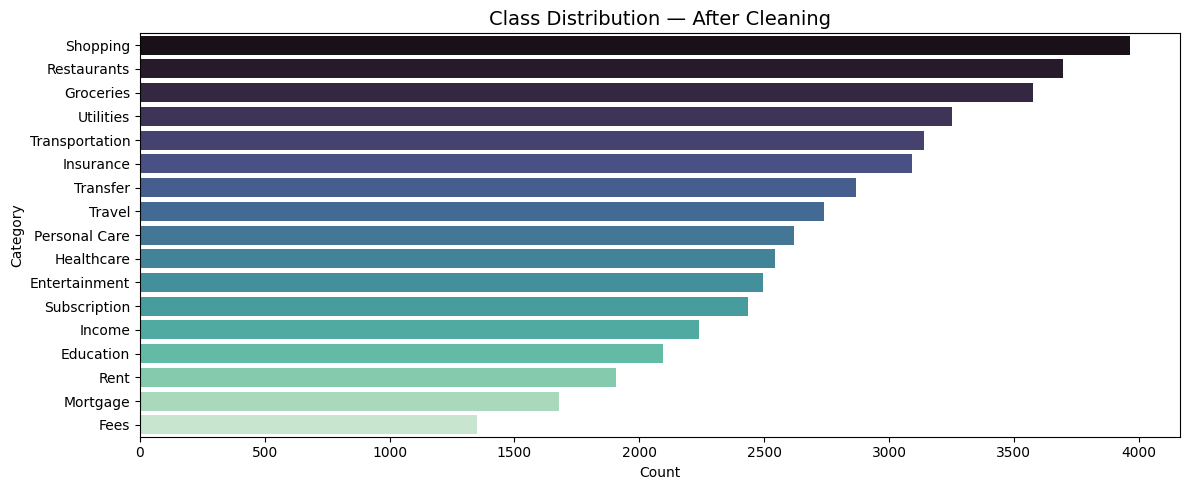

In [ ]:
clean_counts = df["category"].value_counts()
print(clean_counts.to_string())
print(f"\nTotal samples after cleaning: {len(df):,}")

plt.figure(figsize=(12, 5))
sns.barplot(x=clean_counts.values, y=clean_counts.index, palette="mako")
plt.title("Class Distribution — After Cleaning", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 5. Label Encoding
Sort categories alphabetically → assign integer IDs → save `id2label.json`.

In [ ]:
unique_labels = sorted(df["category"].unique().tolist())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label  = {idx: label  for label, idx in label2id.items()}

df["label"] = df["category"].map(label2id)

print(f"Number of classes: {len(unique_labels)}")
print("\nid2label mapping:")
for idx, label in id2label.items():
    print(f"  {idx:2d} → {label}")

Number of classes: 17

id2label mapping:
   0 → Education
   1 → Entertainment
   2 → Fees
   3 → Groceries
   4 → Healthcare
   5 → Income
   6 → Insurance
   7 → Mortgage
   8 → Personal Care
   9 → Rent
  10 → Restaurants
  11 → Shopping
  12 → Subscription
  13 → Transfer
  14 → Transportation
  15 → Travel
  16 → Utilities


### 5.1 Save Mapping Files (commit these to GitHub)

In [ ]:
with open("data/id2label.json", "w") as f:
    json.dump(id2label, f, indent=2)

with open("data/label2id.json", "w") as f:
    json.dump(label2id, f, indent=2)

print("Saved: data/id2label.json  ← commit this to GitHub")
print("Saved: data/label2id.json  ← commit this to GitHub")

# Preview the file
with open("data/id2label.json") as f:
    print("\nContents of id2label.json:")
    print(f.read())

Saved: data/id2label.json  ← commit this to GitHub
Saved: data/label2id.json  ← commit this to GitHub

Contents of id2label.json:
{
  "0": "Education",
  "1": "Entertainment",
  "2": "Fees",
  "3": "Groceries",
  "4": "Healthcare",
  "5": "Income",
  "6": "Insurance",
  "7": "Mortgage",
  "8": "Personal Care",
  "9": "Rent",
  "10": "Restaurants",
  "11": "Shopping",
  "12": "Subscription",
  "13": "Transfer",
  "14": "Transportation",
  "15": "Travel",
  "16": "Utilities"
}


## 6. Train / Validation Split
Stratified 80/20 split — preserves class proportions in both sets.

In [ ]:
train_df, val_df = train_test_split(
    df[["text", "label", "category"]],
    test_size=0.20,
    stratify=df["label"],
    random_state=42,
)

print(f"Train size      : {len(train_df):,}")
print(f"Validation size : {len(val_df):,}")

# Verify stratification
print("\nClass proportions — train vs val:")
train_prop = train_df["category"].value_counts(normalize=True).rename("train_%")
val_prop   = val_df["category"].value_counts(normalize=True).rename("val_%")
print(pd.concat([train_prop, val_prop], axis=1).round(3).to_string())

Train size      : 36,561
Validation size : 9,141

Class proportions — train vs val:
                train_%  val_%
category                      
Shopping          0.087  0.087
Restaurants       0.081  0.081
Groceries         0.078  0.078
Utilities         0.071  0.071
Transportation    0.069  0.069
Insurance         0.068  0.068
Transfer          0.063  0.063
Travel            0.060  0.060
Personal Care     0.057  0.057
Healthcare        0.056  0.056
Entertainment     0.055  0.055
Subscription      0.053  0.053
Income            0.049  0.049
Education         0.046  0.046
Rent              0.042  0.042
Mortgage          0.037  0.037
Fees              0.030  0.030


### 6.1 Save Data Files (add to .gitignore — do NOT commit)

In [ ]:
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/val.csv",   index=False)

print("Saved: data/train.csv  ← add to .gitignore")
print("Saved: data/val.csv    ← add to .gitignore")
print()
print("Recommended .gitignore entries:")
print("  data/train.csv")
print("  data/val.csv")

Saved: data/train.csv  ← add to .gitignore
Saved: data/val.csv    ← add to .gitignore

Recommended .gitignore entries:
  data/train.csv
  data/val.csv


## 7. Summary

In [ ]:
print("=" * 55)
print("  TASK 2 — DATA PREPARATION SUMMARY")
print("=" * 55)
print(f"  Raw rows              : {len(ds['train']):,}")
print(f"  After cleaning        : {len(df):,}")
print(f"  Number of classes     : {len(unique_labels)}")
print(f"  Train split           : {len(train_df):,}")
print(f"  Validation split      : {len(val_df):,}")
print()
print("  Files to commit to GitHub:")
print("    data/id2label.json")
print("    data/label2id.json")
print()
print("  Files to add to .gitignore:")
print("    data/train.csv")
print("    data/val.csv")
print("=" * 55)

  TASK 2 — DATA PREPARATION SUMMARY
  Raw rows              : 68,000
  After cleaning        : 45,702
  Number of classes     : 17
  Train split           : 36,561
  Validation split      : 9,141

  Files to commit to GitHub:
    data/id2label.json
    data/label2id.json

  Files to add to .gitignore:
    data/train.csv
    data/val.csv
